# Speculative Decoding

# Helper Functions

In [5]:
import torch
from gpt_model import GPTModel
import sys
!{sys.executable} -m ensurepip --default-pip

Looking in links: /var/folders/q_/wyvd_ntj4915kskfgx_zsnth0000gn/T/tmpu2xzynq4


In [6]:
!{sys.executable} -m pip install pandas

In [7]:
import sys
!{sys.executable} -m pip install seaborn

In [8]:
# detect what hardware is available
# basically, detect the best fastest available processor
# on our computer so that our GPT model doesn't run at 
# a snail's pace on the CPU if a better option exists.

# check for an NVIDIA graphics card with CUDA drivers installed
# GOLD STANDARD

def pick_device():
    if torch.cuda.is_available():
        device = torch.device("cuda")
    # check for apple GPUs built into M1, M2 or M3 chips
    elif torch.backends.mps.is_available():
        # Only use GPU on a mac if the PyTorch supports it
        major, minor = map(int, torch.__version__.split(".")[:2])
        if (major, minor) >= (2, 9):
            device = torch.device("mps")
        else:
            device = torch.device("cpu")
    # fallback to CPU
    else:
        device = torch.device("cpu")

    return device

In [9]:
# Helper to download open weights for GPT-2.0, 
# already in PyTorch format.

import requests
import os

def download_weights_from_openai(filename):
    url = f"https://huggingface.co/rasbt/gpt2-from-scratch-pytorch/resolve/main/{filename}"
    
    if not os.path.exists(filename):
        print(f"Downloading {filename}...")
        # 'verify=False' bypasses the SSL check entirely
        response = requests.get(url, verify=False)
        with open(filename, "wb") as f:
            f.write(response.content)
        print(f"Successfully downloaded to {filename}!")
    else:
        print(f"{filename} already exists.")

In [10]:
# map the downloaded weights to my own class for GPT-2.0

def load_model(weights_path, config, device):
    model = GPTModel(config)

    # Load the state dictionary
    pretrained_state_dict = torch.load(
        weights_path, map_location=device, weights_only=True
    )

    # Create a new dict with updated keys
    new_state_dict = {}
    for key, value in pretrained_state_dict.items():
        new_key = key
        # Map attributes: 'trf_blocks' -> 'transformer_blocks',
        # 'att' -> 'mha', 'norm1' -> 'layerNorm1', 'norm2' -> 'layerNorm2'
        new_key = new_key.replace("tok_emb", "sem_emb")
        new_key = new_key.replace("trf_blocks", "transformer_blocks")
        new_key = new_key.replace(".att.", ".mha.")
        new_key = new_key.replace(".norm1.", ".layerNorm1.")
        new_key = new_key.replace(".norm2.", ".layerNorm2.")

        new_state_dict[new_key] = value

    # 4. Load the remapped state dict
    model.load_state_dict(new_state_dict)
    print("successfully mapped the model weights to our architecture")

    return model

# Setup the draft and target models

## Load the draft model

In [11]:
GPT_CONFIG_124M_OPEN_AI = {
    "vocab_size": 50257,   # Vocabulary size
    "context_length": 1024, # Shortened context length (orig: 1024)
    "emb_dim": 768,        # Embedding dimension
    "n_heads": 12,         # Number of attention heads
    "n_layers": 12,        # Number of layers
    "drop_rate": 0.1,      # Dropout rate
    "qkv_bias": True,      # Query-key-value bias
    "weight_tying": False
}
GPT_CONFIG_DRAFT = GPT_CONFIG_124M_OPEN_AI

In [12]:
path_to_draft_model = "gpt2-small-124M.pth"

download_weights_from_openai(filename=path_to_draft_model)
draft_model = load_model(
    weights_path=path_to_draft_model,
    config=GPT_CONFIG_124M_OPEN_AI,
    device=pick_device(),
)

gpt2-small-124M.pth already exists.
successfully mapped the model weights to our architecture


## Load the Target Model

In [13]:
_GPT_CONFIG_1558M_OPEN_AI = {
    "vocab_size": 50257,   # Vocabulary size
    "context_length": 1024, # 
    "emb_dim": 1600,        # Embedding dimension
    "n_heads": 25,         # Number of attention heads
    "n_layers": 48,        # Number of transformer layers
    "drop_rate": 0.1,      # Dropout rate
    "qkv_bias": True,      # Query-key-value bias
    "weight_tying": False
}

In [14]:
GPT_CONFIG_355M_OPEN_AI = {
    "vocab_size": 50257,   # Vocabulary size
    "context_length": 1024, # 
    "emb_dim": 1024,        # Embedding dimension
    "n_heads": 16,         # Number of attention heads
    "n_layers": 24,        # Number of transformer layers
    "drop_rate": 0.1,      # Dropout rate
    "qkv_bias": True,      # Query-key-value bias
    "weight_tying": False
}

In [15]:
path_to_target_model = "gpt2-medium-355M.pth"

download_weights_from_openai(filename=path_to_target_model)
target_model = load_model(
    weights_path=path_to_target_model,
    config=GPT_CONFIG_355M_OPEN_AI,
    device=pick_device(),
)

gpt2-medium-355M.pth already exists.
successfully mapped the model weights to our architecture


# Generate tokens with the draft model

## Warm-up: Sample the entire sequence from the draft model only

In [16]:
def generate(model, current_sequence, number_of_tokens, context_size):
    for _ in range(number_of_tokens):
        # clip the input to context_window size
        # ex: keep the last 5 tokens if the context size is 5
        cropped_context = current_sequence[:, -context_size:]
        # # convert the input into token ids
        # input_tokens = text_to_tokens(current_sequence)

        with torch.no_grad():
            logits, _kv_cache = model(cropped_context)

        # focus only on the last token's logits
        logits = logits[:, -1, :]

        # convert the logits into probabilities
        probas = torch.softmax(logits, dim=-1)  # batch, vocab_size

        # sample greedily - pick the one with the highest probability
        next_idx = torch.argmax(probas, dim=-1, keepdim=True)

        current_sequence = torch.cat(
            (current_sequence, next_idx), dim=1
        )  # batch, n_tokens+1

    return current_sequence

In [17]:
# helper functions for tokenization

import tiktoken
from tokenization_helper import text_to_token_ids, token_ids_to_text

tokenizer = tiktoken.get_encoding("gpt2")

In [18]:
# call the draft model and verify it generates text

torch.manual_seed(123)

token_ids = generate(
    model=draft_model,
    current_sequence=text_to_token_ids("Every effort moves you", tokenizer).to(
        pick_device()
    ),
    number_of_tokens=15,
    context_size=GPT_CONFIG_DRAFT["context_length"],
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you can't make.


The only way to make a good game


## Generate K-tokens at a time using the draft model

In [19]:
# this is gonna be very similar to the generate function above,
# except that we'll also keep track the probability vector
# for the last token at each generation step

# this will return the (prefix + k decoded tokens), 
# along with the probas for each of the k decoded tokens
def draft_lookahead_tokens(model, current_sequence, k, context_size, temperature=1.0):
    # current_sequence is a 2D tensor: [1, sequence_length].
    draft_probas = []

    for _ in range(k):
        cropped_context = current_sequence[:, -context_size:]

        with torch.no_grad():
            # this tells PyTorch to disable the gradient calculation engine,
            # thereby saving memory (stops taking derivatives, so no training).
            # otherwise PyTorch remembers every operation (mul, add, etc.) so
            # that it can calc gradients during backprop much quicker.
            logits, _kv_cache = model(cropped_context)

        # focus only on the last token
        # (batch, n_tokens, vocab_size) becomes (batch, vocab_size)
        logits = logits[:, -1, :]

        # apply temperature scaling
        if temperature > 0:
            logits = logits / temperature
            # The shape of probas will be [batch, vocab_size]
            # (ex: [1, 50257]).
            probas = torch.softmax(logits, dim=-1)
            draft_probas.append(probas)
            next_idx = torch.multinomial(probas, num_samples=1)
        else:
            # 1. sample a token greedily
            # - keep the dimension after performing the argmax
            # so, instead of returning a 1-D tensor of size [batch],
            # it returns 2-D tensor of size [batch, 1] - ex:
            # tensor([[4], [7], [1]]) # Shape is [3, 1], instead of
            # tensor([4, 7, 1])  # Shape is [3]
            next_idx = torch.argmax(logits, dim=-1, keepdim=True)

            # 2. Build a true one-hot tensor matching the vocab size
            # This ensure Q = 1.0 for the choice and 0.0 everywhere else
            # since we can't pass a smooth, non-greedy distribution back
            # to the main verification loop
            # If we pass the raw softmax distribution instead,
            # our verification step will run a fractional probability
            # check (p/q) using a smooth curve, allowing the random roll
            # fallback to trigger on a greedy pass. This will break the
            # mathematical guarantee that the output is 100%
            # identical to the target model!
            one_hot_probas = torch.zeros_like(logits)
            one_hot_probas.scatter_(
                dim=-1,
                index=next_idx,
                src=torch.ones_like(next_idx, dtype=logits.dtype),
            )

            # The shape of probas will be [batch, vocab_size]
            # (ex: [1, 50257]).
            draft_probas.append(one_hot_probas)

        # since we did keep dim above, we can cat the two
        # tensors since both are 2-D
        current_sequence = torch.cat(
            (current_sequence, next_idx), dim=1
        )  # batch, n_tokens+1

    return (
        current_sequence,
        # Stack along dim=1 to get a single tensor of shape
        # [batch, K, vocab_size]
        torch.stack(draft_probas, dim=1),
    )

# Score the generated tokens using the Target Model

In [20]:
# we'll pass the entire draft sequence into the
# target model in 1 pass


def score_target_tokens(
    target_model, extended_sequence, k, context_size, temperature=1.0
):
    # say our original sequence had a length of N=10
    # we had the draft model generate K=4 more tokens
    # so, extended_sequence now has 14 tokens
    # when we pass these 14 tokens through the target model,
    # we get back 14 probability vectors
    #  prediction at index-0 will be the prob of token at idx 1
    #  prediction at index-1 will be the prob of token at idx 2
    #  prediction at index-13 will be the prob of token at idx 14

    # to correctly align with the K draft tokens for verification,
    # we need to slice the last K+1 indices from the target model's
    # output probability tensors!

    # basically, the target model gives us a bonus token at the end.

    # 1. crop the extended sequence to the max context length
    cropped_extended_sequence = extended_sequence[:, -context_size:]

    # 2. run a forward pass through the target model
    with torch.no_grad():
        logits, _kv_cache = target_model(cropped_extended_sequence)

    # apply temperature scaling
    if temperature > 0:
        logits = logits / temperature
        # 3. convert logits into probas
        probas = torch.softmax(logits, dim=-1)
    else:
        # Find the greedy choice at each position across the sequence length
        greedy_indices = torch.argmax(logits, dim=-1, keepdim=True)

        # Construct a perfect one-hot distribution matching the logit shape
        probas = torch.zeros_like(logits)
        probas.scatter_(
            dim=-1,
            index=greedy_indices,
            src=torch.ones_like(greedy_indices, dtype=logits.dtype),
        )

    # since the model is autoregressive, the index of the
    # output probability vector is shifted by 1 relative to the
    # token it is predicting. hence,
    # probas[:, 9, :] scores Draft Token 1 (input index 10)
    # probas[:, 10, :] scores Draft Token 2 (input index 11)
    # probas[:, 11, :] scores Draft Token 3 (input index 12)
    # probas[:, 12, :] scores Draft Token 4 (input index 13)
    # probas[:, 13 :] predicts a bonus token (input index 14)

    # hence, we only need to verify the tokens at
    # indices 9, 10, 11, 12 => 4 tokens that are between
    # positions -(k+1) and -1, hence [:,-(k+1):-1,:]

    # 4. slice out the prob vectors needed for verification of 
    # the k-tokens
    target_verify_probas = probas[:, -(k + 1) : -1, :]

    # 5. return the proba of the bonus token as well
    # which will be used if the model accepts all K
    # draft tokens
    target_bonus_proba = probas[:, -1:, :]

    return target_verify_probas, target_bonus_proba

## Verifying the Draft Tokens

In [21]:
def verify_draft_tokens(
    draft_ids, draft_probas, target_verify_probas, target_bonus_proba, k
):
    # draft_ids - [batch, K]
    # draft_probas - [batch, k, vocab_size]
    # target_verify_probas - [batch, k, vocab_size]
    # target_bonus_proba - [batch, 1, vocab_size]

    accepted_count = 0

    for i in range(k):
        # get the token id that was sampled by the draft model
        # at step i
        token_id = draft_ids[:, i : i + 1] # [batch, 1]

        # 1. Get the 2D probability distributions for just step i
        q_distribution = draft_probas[:, i, :] # [batch, vocab_size]
        p_distribution = target_verify_probas[:, i, :] # [batch, vocab_size]

        # 2. Extract the exact scalar probabilities for the token_id
        #  - gather looks along the vocabulary dimension (dim=-1)
        #    using token_id as the map
        q = torch.gather(q_distribution, dim=-1, index=token_id) # [batch, 1]
        p = torch.gather(p_distribution, dim=-1, index=token_id) # [batch, 1]

        # print(f"Token: '{token_ids_to_text(token_id, tokenizer)}':")
        # print(f"p={p}, q={q}, p/q={p/q}")

        if p >= q:
            # print(f"target model **agreed**")
            accepted_count += 1
        else:
            # print(f"target model **disagreed**")
            # Let's say for position X
            # - target's proba for the token "dog" is 40% (p)
            # - draft's proba for the token "dog" is 80% (q)
            # Hence, p < q.
            # However, we still accept q (p/q = 50%) times.
            # As a result, 50% of 80% = 40%, so we still
            # end up accepting dog 40% of the times, which
            # aligns with what the target model would've done!
            
            # Roll a random number U, between 0 and 1
            random_roll = torch.rand(1, device=p.device)

            # for the temp = 0 case:
            #     * if draft and target agree on the token
            #       (the most probable token in their respective distributions is the same)
            #       then p = q = 1
            #     * if they disagree, then p will be 0 and q will be 1 (because of the 
            #       one-hots), so the following p/q becomes 0/1 and is safe from division by 0.

            if random_roll <= (p / q):
                # if U <= (p/q), accept it anyway and keep going
                # - basically, Target would've accepted this token p% (say 40%) times, and
                #   Draft wants it q% times (say 80%). So, acceptance rate is 40/80 = 50%
                # - hence, if we roll 0.5 or less, we accept the draft's proposal.                
                accepted_count += 1
                # print(
                #     f"{token_ids_to_text(token_id, tokenizer)}: target model **accepted based on roll: {random_roll}**"
                # )
            else:
                # if U > (p/q), reject and sample from the adjusted residual distribution
                # print(
                #     f"{token_ids_to_text(token_id, tokenizer)}: target model **rejected** based on roll: {random_roll}**"
                # )

                # Basically, let's say we rolled 0.51 and now we've rejected "dog".
                # So, we cannot now just normally sample from the Target's distribution.
                # This is because, the target's usual prob distribution would still 
                # pick "dog" 40% of the times, but we just rejected that.
                # Hence, we must sample from the residual distribution of p-q.
                # So, "dog" would now be sampled (40-80) = -40% of the times.
                
                # Since probabilities cannot be <0, we "clamp" the distribution so that
                # the probability of picking "dog" is set at 0.
                residual_logits = torch.clamp(p_distribution - q_distribution, min=0)

                # Finally, we normalize this residual distribution so all the probs now
                # sum to 1.0
                sum_residual = residual_logits.sum(dim=-1, keepdim=True)
                residual_probas = residual_logits / torch.where(
                    sum_residual > 0, sum_residual, 1.0
                )

                # Sample probabilistically from the remaining distribution
                next_token_id = torch.multinomial(residual_probas, num_samples=1)

                # if we hit a mismatch, the future tokens can no longer be accepted either, 
                # just return immediately
                return accepted_count, next_token_id

    bonus_distribution = target_bonus_proba[:, 0, :]
    next_token_id = torch.multinomial(bonus_distribution, num_samples=1)

    return accepted_count, next_token_id

Look at my comments in the code above for my understanding.
Following are some notes from my convo with Gemini


### 1. If the draft model picks a "non-best" token (Token B) at Step 1, and the target model accepts it because $P \ge Q$, doesn't that permanently derail the future text? If we had run the target model alone, it would have picked its absolute favorite token (Token A). Now that Token B is in the prompt, won't the rest of the sentence be different?

The answer is **yes, the sentence will be completely different from that point onward.** But here is the trick: **That is exactly what would have happened if we ran the target model alone under temperature sampling anyway.**

Let’s look at why this is true, step-by-step.

---

#### The Misconception: Confusing "Target Model Native" with "Greedy Search"

When we sample with a temperature (like $T=0.7$), the target model **never** just picks its favorite token every time. It behaves like a wheel of fortune.

Let's look at the true target model distribution for a prompt:

* **Token A ("cat"):** 60% chance
* **Token B ("dog"):** 30% chance
* **Token C ("banana"):** 10% chance

If you ran the target model completely by itself for 100 independent trials, it would output "cat" 60 times, but it would also natively output "dog" 30 times and "banana" 10 times. All three outcomes are 100% authentic, correct "target model outputs."

#### How the Draft Model Intersects This

Now let’s look at what happens in Speculative Decoding. The draft model creates its own wheel of fortune for that same step. Because it's smaller, its percentages are slightly distorted:

* **Token A ("cat"):** 40% chance
* **Token B ("dog"):** 50% chance (The draft model over-hyped this one!)
* **Token C ("banana"):** 10% chance

Let's say the draft model spins its wheel, and it lands on **Token B ("dog")**.

We take Token B to the target model judge. The target model checks its own native brain: *"Do I ever say 'dog' here? Yes, I say it 30% of the time ($P=0.30$). The draft model sampled it at 50% ($Q=0.50$)."*

Because $P < Q$, the target model doesn't automatically pass it. It runs the exact ratio check we wrote:


$$\frac{P}{Q} = \frac{0.30}{0.50} = 60\% \text{ chance to accept}$$

We roll our random dice $U$. Let's say $U = 0.42$. Since $0.42 \le 0.60$, **the target model accepts Token B ("dog")**.

---

#### The Magical Realization

Think about what just happened:

1. The draft model proposed "dog".
2. The target model mathematically filtered that proposal through a probability gate ($\frac{P}{Q}$).
3. The end result is that "dog" was accepted.

If you multiply the draft model's original chance of picking "dog" ($50\%$) by the target model's probability gate of keeping it ($60\%$), you get:


$$0.50 \times 0.60 = 0.30 \implies \mathbf{30\%}$$

Look at that number. **30% is the exact, native probability that the target model would have picked "dog" entirely on its own!**

#### Looking Forward: Why the future text remains valid

Yes, because "dog" was picked instead of "cat," the sentence will now go in a completely different direction. If the sentence becomes `"I saw a dog..."`, the next tokens will be about barking or leashes, whereas `"I saw a cat..."` would have been about purring or mice.

But because the math forced the probability of getting "dog" to be *exactly* 30%, **the distribution of sentences leaving a speculative decoding system is identical to the distribution of sentences leaving a lone target model.**

If you run Speculative Decoding 1,000 times and a lone Target Model 1,000 times on the same prompt with the same random seeds:

* Both systems will generate a story about a "cat" roughly 600 times.
* Both systems will generate a story about a "dog" roughly 300 times.

The text isn't the same as a *greedy* target model search, but it is **mathematically indistinguishable** from a target model running with temperature. The draft model didn't hijack or ruin the target model's creativity—the target model's acceptance gate forced the draft model's flawed guesses to perfectly conform to its own native worldview.


### 2. Can you explain the residual probability

Let's dive into the **residual probability distribution** for the non-zero temperature case. This is where the mathematical brilliance of speculative decoding truly shines.

When temperature is greater than zero ($T > 0$) and a draft token gets rejected by the random roll, we cannot just look up the target model's single favorite token like we do at $T=0$. We have an entire vocabulary of choices, and we must sample a replacement token from a modified distribution.

The goal of this modified distribution—the **residual distribution**—is to answer a precise question:
*"Since we are rejecting this specific draft token, how do we adjust the remaining options so that the target model's original voice is perfectly preserved?"*

---

#### Step 1: Why We Can't Just Use the Original Target Distribution ($P$)

Imagine the target model's original distribution ($P$) and the draft model's distribution ($Q$) look like this for three words:

* **"apple":** Target ($P$) = 60%, Draft ($Q$) = 20%
* **"banana":** Target ($P$) = 30%, Draft ($Q$) = 10%
* **"cherry":** Target ($P$) = 10%, Draft ($Q$) = 70% *(Draft model went way too aggressive here)*

Let's say the draft model samples **"cherry"**. We test it against the target model, the random roll fails, and **"cherry" is rejected**.

If we simply sampled our correction token from the target's original distribution ($P$), we would be committing a statistical crime. Why? Because the target model *already had a 10% native chance of picking cherry on its own*. By rejecting a draft "cherry" and then sampling from the full $P$ distribution (which still contains a 10% chance for cherry), "cherry" could theoretically be picked again!

To fix this bias, we must mathematically subtract the draft model's influence from the equation.

---

#### Step 2: The Math of the Residual ($P - Q$)

To build the correction distribution, our code performs a simple element-wise subtraction: **$P - Q$**. Let's calculate $P - Q$ for our words:

* **"apple":** $P - Q = 0.60 - 0.20 = \mathbf{+0.40}$
* **"banana":** $P - Q = 0.30 - 0.10 = \mathbf{+0.20}$
* **"cherry":** $P - Q = 0.10 - 0.70 = \mathbf{-0.60}$

Notice what just happened. For words that the draft model *under-sampled* ("apple" and "banana"), the result is positive. For the word the draft model over-sampled and got rejected on ("cherry"), the result drops below zero.

---

#### Step 3: Clamping the Negatives (`torch.clamp(..., min=0)`)

A probability can never be negative. If the draft model aggressively over-hyped a token, subtracting it drives the value into negative territory. our code uses `torch.clamp(..., min=0)` to instantly zero those out:

* **"apple":** +0.40 $\rightarrow$ **0.40**
* **"banana":** +0.20 $\rightarrow$ **0.20**
* **"cherry":** -0.60 $\rightarrow$ **0.00** *(Completely banned from being selected as the correction token!)*

---

#### Step 4: Normalization (Scaling back to 100%)

Right now, our residual values are: `[0.40, 0.20, 0.00]`.

If you add those up, they sum to `0.60`. This is not a valid probability distribution because it doesn't add up to 1.0 (100%).

To fix this, our code calculates the sum (`0.60`) and divides each element by it:

* **"apple":** $\frac{0.40}{0.60} = \mathbf{66.6\%}$
* **"banana":** $\frac{0.20}{0.60} = \mathbf{33.3\%}$
* **"cherry":** $\frac{0.00}{0.60} = \mathbf{0\%}$

Now we have a flawless, valid probability distribution summing to 100%. When our code runs `torch.multinomial` on this normalized tensor, it will sample a correction token. In this case, it has a 2/3 chance of picking "apple" and a 1/3 chance of picking "banana".

---

#### The Big Picture Intuition

The residual distribution acts as an **equalizer**.

By calculating $\max(0, P - Q)$ and normalizing it, the target model looks at the remaining vocabulary and says:

> *"The draft model messed up and gave me an over-hyped token that I rejected. I am now going to look at the other options ('apple' and 'banana'). Because I liked 'apple' twice as much as 'banana' originally (60% vs 30%), my correction distribution will maintain that exact 2-to-1 preference ratio (66.6% vs 33.3%), while completely erasing the mistake from existence."*

This exact adjustment is the final mathematical puzzle piece. It guarantees that even when rejections happen under non-zero temperatures, the statistical voice of our 355M target model remains perfectly pure and unaltered.


---

### 3. Why do we still accept the draft's token based on the random roll, even though p < q?

Imagine the draft model guesses the word "pizza" with a 60% chance ($Q = 0.60$).The target model looks at its own brain and says, "Eh, I only give 'pizza' a 30% chance here" ($P = 0.30$).Since $P < Q$, the target model disagrees. But instead of throwing it in the trash instantly, we look at the ratio of their confidence:$$\frac{P}{Q} = \frac{0.30}{0.60} = 0.50 \text{ (a 50% chance)}$$

We roll a random number $U$ between 0.0 and 1.0. If that number is $0.50$ or lower, we say, "You know what? Close enough." and accept it anyway.

**Why do this?** It mathematically guarantees that our final generated text perfectly matches the exact probability distribution of the big target model, while still letting us keep a "good enough" draft token to save time.


### 4. An example of the residual distribution

| Token      | Target Model (P) | Draft Model (Q) | Residual (P - Q)      |
| ---------- | ---------------- | --------------- | --------------------- |
| `"burger"` | 70%              | 10%             | 60%                   |
| `"pizza"`  | 30%              | 90%             | -60% → (Clamped to 0) |

Now we have a perfectly clean, adjusted distribution representing only the options the target model felt the draft model missed out on. We sample from that to get our clean correction token (next_token_id), and then we move on to the next cycle.


### 5. > If the target model thinks that guess is the absolute best choice ($P \geq Q$), it's an automatic pass - why is this the case - we are just comparing the prob of the selected token between the draft and target and accepting it if the target is higher. However, couldn't the target have had some other token that was even higher, but wasn't picked by the draft model?

Vidhant's version: Yes, maybe for this pass, we won't get the exact same output as the target would've picked, but over 1000s of runs, the distribution of our ouputs will exactly match the distribution of the Target's outputs.

---

**Yes, the target model could absolutely have a different token that it prefers even more.**

However, we still accept the draft model's token automatically if $P \geq Q$. Here is why that is not just allowed, but mathematically mandatory to keep the generation accurate.

---

#### 1. We aren't trying to find the "Absolute Best" token

The goal of speculative decoding isn't to make the big target model output its single favorite token at every step. If we did that, the text would be 100% deterministic (greedy search), which makes language models sound repetitive and robotic.

Instead, our goal is to **exactly mimic the probability distribution** of the target model, as if we had run the big model normally.

---

#### 2. The Draft Model already paid the "Probability Tax"

Think of the draft model as a filter that proposes a token. By the time a token reaches the target model for verification, it has *already* survived the draft model's internal probability check.

When the target model sees that the draft model picked a token and notes that $P \geq Q$, the target model is essentially saying:

> *"Wow, you gave this token a $10\%$ chance, but in my massive brain, I actually give it a $30\%$ chance. You under-sampled it compared to what I would do. Therefore, I am completely safe to accept this, because it fits comfortably inside my own probability budget."*

---

#### 3. How the "Other, Higher Token" Eventually Wins

What about that other token the target model liked *even more*? If the draft model missed it this time, does it just get ignored forever?

No! Because we are running this over thousands of tokens across many steps, the math balances out beautifully over time:

* **In this exact step:** The draft model happened to guess a token that the target model agreed was valid ($P \geq Q$). We accept it and move on. We "missed" the target's favorite token for this specific slot, but the token we kept is still mathematically valid under the target's distribution.
* **In future steps:** Because the target model has a massive preference for that other concept, the *draft model* (which is trained to mimic the target model) will naturally start guessing those preferred tokens in subsequent steps.

#### The Mathematical Guarantee

Speculative decoding relies on a proof showing that if you follow this exact acceptance rule ($P \geq Q$ automatic pass, and the $\frac{P}{Q}$ random roll fallback), the final output text is **proverbially indistinguishable** from text generated by running the big target model entirely on its own.

**You aren't losing the target model's intelligence; you are just letting the draft model steer the path, and the target model acts as a guardrail saying *"Yes, this path is plausible"* or *"No, this path is completely out of character for me, let me rewrite it using the residual distribution."***


### 6. How does the above change if the temp was zero (Greedy decoding)?

Vidhant's version: In this case, the final output will match the Target's output every single time.

---
When you enforce greedy search, you change the rules of the probability game:
* The target model will only accept a token if it is the absolute top choice.
* The math behind the random roll fallback disappears because we aren't dealing with a distribution anymore—we are only dealing with the #1 token.

### 7. Why do we need special handling (one-hot vectors) in the draft and target model generation loops for T=0?

Vidhant's version: This also makes our code-handling smoother

* If target (p) and draft (q) agree on a token, then p = q = 1 and the p>=q condition will be true and we'll accept the token
* If target (p) disagrees from the draft (q) on a token, then p will be 0, while q will be 1, so random_roll <= p/q will yield 0/1 for the RHS - which is safe from divisions by zero and also ensures we reject the token proposed by the draft.

**Basically, then T=0, the choices are no longer probabilistic - the target and draft are very fixated on picking exactly one token - the the one-hot vectors represent this really well (all probs are 0 except for exactly one)**

From Gemini: 
If we hadn't outputted a one-hot vector from the draft model either—meaning **both** our draft model ($Q$) and our target model ($P$) were passing their raw, smooth softmax distributions to the validation loop at $T=0$—our original code would run, but we would be breaking a fundamental law of speculative decoding.

Here is exactly what happens mathematically and why it degrades the system.

---

#### 1. We Lose the "Greedy" Guarantee (Output Divergence)

At $T=0$, our draft model selects its token via `torch.argmax`. Let's say it greedily picks `"apple"`.

If it passes its *smooth* distribution, $Q(\text{"apple"})$ might only equal `0.40`, even though it was the top choice. Now, let's say the target model also thinks `"apple"` is the top choice, but its smooth probability $P(\text{"apple"})$ is `0.35`.

Our automatic check fails because $0.35 \ge 0.40$ is **False**. The loop drops back to the random roll fallback:

$$\text{if } U \le \frac{P(\text{"apple"})}{Q(\text{"apple"})} \implies U \le \frac{0.35}{0.40} \implies U \le 0.875$$

We now roll a uniform random variable $U$. There is a **12.5% chance** that the token is rejected.

If it gets rejected, the target model samples a replacement token from the residual distribution $\max(0, P - Q)$. Because this is a stochastic roll, it might pick `"banana"`.

**The Catastrophe:** Our target model's true greedy choice was `"apple"`. But because of the smooth distribution mismatch, a random roll failed, and the system spit out `"banana"`. Our speculative decoding algorithm is no longer deterministic—**it is generating different text than a standard greedy target model would.**

---

#### 2. Cascading Rejections (Wasted Speedup)

Speculative decoding relies on a high acceptance rate to get a wall-clock speedup.

If both models pass smooth curves, even when they completely agree on the exact sequence of tokens, the fractional math ($\frac{P}{Q}$) will constantly trigger random rolls. Some of those rolls will inevitably fail by pure statistical chance.

The moment a roll fails, the entire remaining draft chain ($K$ tokens) is thrown in the trash. Our average token acceptance rate will plummet, forcing the target model to execute far more forward passes than necessary. We'll completely erase the exact performance gains we are trying to benchmark.

---

#### Summary

The one-hot vectors perfectly immunizes our implementation against both issues. Because $Q$ is exactly `1.0` for the chosen token, the target model's $P$ must also be exactly `1.0` (thanks to the matching one-hot fix we put in `score_target_tokens`).

The validation condition evaluates to $1.0 \ge 1.0$, which is unconditionally **True**. Zero random numbers are generated, rejections only happen if the models genuinely disagree on the top token, and our output remains mathematically identical to a native greedy run.

# Speculative Decoding Loop

In [22]:
def speculative_decode(
    prefix_ids, draft_model, target_model, max_new_tokens, k, context_size
):
    current_sequence = prefix_ids.clone()
    target_len = current_sequence.shape[1] + max_new_tokens

    while current_sequence.shape[1] < target_len:
        # print(f"Sequence at the start of the iteration: {token_ids_to_text(current_sequence, tokenizer)}")
        
        # 1. Run the draft generation loop for K steps
        num_before_draft = current_sequence.shape[1]
        extended_seq, draft_probs = draft_lookahead_tokens(
            draft_model, current_sequence, k, context_size
        )
        # print(f"Draft model generated: {token_ids_to_text(extended_seq, tokenizer)}")

        # Isolate just the newly guessed token IDs from the draft model
        draft_ids = extended_seq[:, num_before_draft:]

        # 2. Score the entire extended sequence with the Target Model in parallel
        target_verify_probas, target_bonus_proba = score_target_tokens(
            target_model, extended_seq, k, context_size
        )
        

        # 3. Verify the tokens using the verification function
        accepted_count, next_token_id = verify_draft_tokens(
            draft_ids, draft_probs, target_verify_probas, target_bonus_proba, k
        )
        # print(f"Target model accepted {accepted_count} and suggested the next token as '{token_ids_to_text(next_token_id, tokenizer)}'")

        # 4. Update the sequence history: Keep the original sequence,
        # append any valid draft slices, and append the final bonus token
        if accepted_count > 0:
            valid_draft_tokens = draft_ids[:, :accepted_count]
            current_sequence = torch.cat((current_sequence, valid_draft_tokens), dim=1)

        current_sequence = torch.cat((current_sequence, next_token_id), dim=1)
        # print(f"Sequence at the end of the iteration: {token_ids_to_text(current_sequence, tokenizer)}")
        # print("="*50)

    return current_sequence

In [23]:
# call the draft model and verify it generates text

torch.manual_seed(123)

token_ids = speculative_decode(
    prefix_ids=text_to_token_ids("India gained its", tokenizer).to(pick_device()),
    draft_model=draft_model,
    target_model=target_model,
    max_new_tokens=15,
    k=5,
    context_size=GPT_CONFIG_DRAFT["context_length"],
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 India gained its power from Gaugamikar: these islands are the cities of gift and


# Experiments

In [24]:
import time


def speculative_decode_with_metrics(
    prefix_ids,
    draft_model,
    target_model,
    max_new_tokens,
    k,
    context_size,
    temperature=1.0,
):
    # same as previous cell, but with metric tracking
    current_sequence = prefix_ids.clone()
    start_tokens = current_sequence.shape[1]
    target_len = start_tokens + max_new_tokens

    metrics = {
        "total_draft_tokens_generated": 0,
        "total_draft_tokens_accepted": 0,
        "target_forward_passes": 0,
        "total_tokens_emitted": 0,
        "acceptance_by_position": [0] * k,
        "wall_clock_time": 0.0,
        "tokens_per_second": 0.0,
        "acceptance_rate": 0.0,
    }

    start_time = time.perf_counter()

    while current_sequence.shape[1] < target_len:
        # print(
        #     f"Sequence at the start of the iteration: {token_ids_to_text(current_sequence, tokenizer)}"
        # )

        # 1. Run the draft generation loop for K steps
        num_before_draft = current_sequence.shape[1]
        extended_seq, draft_probs = draft_lookahead_tokens(
            draft_model, current_sequence, k, context_size, temperature
        )
        # print(f"Draft model generated: {token_ids_to_text(extended_seq, tokenizer)}")

        # Isolate just the newly guessed token IDs from the draft model
        draft_ids = extended_seq[:, num_before_draft:]

        # 2. Score the entire extended sequence with the Target Model in parallel
        target_verify_probas, target_bonus_proba = score_target_tokens(
            target_model, extended_seq, k, context_size, temperature
        )

        # 3. Verify the tokens using the verification function
        accepted_count, next_token_id = verify_draft_tokens(
            draft_ids, draft_probs, target_verify_probas, target_bonus_proba, k
        )
        # print(
        #     f"Target model accepted {accepted_count} and suggested the next token as '{token_ids_to_text(next_token_id, tokenizer)}'"
        # )

        metrics["target_forward_passes"] += 1
        metrics["total_draft_tokens_generated"] += k
        metrics["total_draft_tokens_accepted"] += accepted_count

        # increment the acceptance count of tokens 1..accepted_count
        for i in range(accepted_count):
            metrics["acceptance_by_position"][i] += 1

        # 4. Update the sequence history: Keep the original sequence,
        # append any valid draft slices, and append the final bonus token
        if accepted_count > 0:
            valid_draft_tokens = draft_ids[:, :accepted_count]
            current_sequence = torch.cat((current_sequence, valid_draft_tokens), dim=1)

        current_sequence = torch.cat((current_sequence, next_token_id), dim=1)
        # print(
        #     f"Sequence at the end of the iteration: {token_ids_to_text(current_sequence, tokenizer)}"
        # )
        # print("=" * 50)
        # Cap the sequence at exactly target_len if it overshot
        if current_sequence.shape[1] >= target_len:
            current_sequence = current_sequence[:, :target_len]
            break

    end_time = time.perf_counter()

    total_generated = current_sequence.shape[1] - start_tokens
    metrics["total_tokens_emitted"] = total_generated
    metrics["wall_clock_time"] = end_time - start_time
    metrics["tokens_per_second"] = total_generated / metrics["wall_clock_time"]
    metrics["acceptance_rate"] = (
        metrics["total_draft_tokens_accepted"] / metrics["total_draft_tokens_generated"]
    )

    return current_sequence, metrics

In [25]:
def generate_target_baseline(
    model, initial_sequence, max_tokens, context_size, temperature=None
):
    if temperature is None or temperature == 0.0:
        temperature = 0.0

    current_sequence = initial_sequence.clone()
    start_tokens = current_sequence.shape[1]

    start_time = time.perf_counter()

    for _ in range(max_tokens):
        cropped_context = current_sequence[:, -context_size:]
        with torch.no_grad():
            logits, _ = model(cropped_context)
        logits = logits[:, -1, :]

        if temperature > 0:
            probas = torch.softmax(logits / temperature, dim=-1)
            next_idx = torch.multinomial(probas, num_samples=1)
        else:
            next_idx = torch.argmax(logits, dim=-1, keepdim=True)

        current_sequence = torch.cat((current_sequence, next_idx), dim=1)

    end_time = time.perf_counter()
    # print(f"Generated: {token_ids_to_text(current_sequence, tokenizer)}")

    return {
        "wall_clock_time": end_time - start_time,
        "tokens_per_second": max_tokens / (end_time - start_time),
    }

In [26]:
import pandas as pd

# Define the hyperparameters for the sweep
temperatures = [0.0, 0.7, 1.0]
k_values = [2, 3, 4, 5, 6]
max_new_tokens = 50
prompt_ids = text_to_token_ids("Humans have a large and highly developed prefrontal cortex, the region of the brain associated with higher cognition. They are intelligent beings, capable of episodic memory, flexible facial expressions, self-awareness and a theory of mind. The human mind is capable of introspection (meta-cognition), private thought, imagination, volition and forming views on existence.", tokenizer).to(pick_device())
context_size = GPT_CONFIG_DRAFT["context_length"]

sweep_results = []

print("🚀 Starting the Sweet-Spot Sweep Benchmark...")
print("-" * 60)

# 1. Baseline: Benchmark the Target Model's tokens_per_second for each temperature
baseline_stats = {}
for temp in temperatures:
    print(f"📊 Running baseline for Target Model alone (T={temp})...")
    baseline_data = generate_target_baseline(
        model=target_model,
        initial_sequence=prompt_ids,
        max_tokens=max_new_tokens,
        context_size=context_size,
        temperature=temp,
    )
    baseline_stats[temp] = baseline_data["tokens_per_second"]

# 2. Run the full Speculative Grid Search
for temp in temperatures:
    for k in k_values:
        print(f"🔄 Executing Speculative Loop: Temperature={temp} | K={k}")

        # Run the speculative generation
        _, metrics = speculative_decode_with_metrics(
            prefix_ids=prompt_ids,
            draft_model=draft_model,
            target_model=target_model,
            max_new_tokens=max_new_tokens,
            k=k,
            context_size=context_size,
            temperature=temp,
        )

        # Calculate the real speedup factor against the baseline of the SAME temperature
        baseline_tps = baseline_stats[temp]
        speculative_tps = metrics["tokens_per_second"]
        speedup_factor = speculative_tps / baseline_tps

        # Store all metrics for data analysis
        sweep_results.append(
            {
                "Temperature": temp,
                "Lookahead_K": k,
                "Acceptance_Rate": metrics["acceptance_rate"],
                "Target_Forward_Passes": metrics["target_forward_passes"],
                "Tokens_Per_Sec": speculative_tps,
                "Baseline_Tokens_Per_Sec": baseline_tps,
                "Speedup_Factor": speedup_factor,
                "Acceptance_By_Position": metrics["acceptance_by_position"],
            }
        )

print("-" * 60)
print("✅ Benchmark complete! Creating dataframe...")

# Convert to DataFrame for instant viewing/plotting
df_results = pd.DataFrame(sweep_results)
display(
    df_results[
        [
            "Temperature",
            "Lookahead_K",
            "Acceptance_Rate",
            "Target_Forward_Passes",
            "Tokens_Per_Sec",
            "Speedup_Factor",
        ]
    ]
)

🚀 Starting the Sweet-Spot Sweep Benchmark...
------------------------------------------------------------
📊 Running baseline for Target Model alone (T=0.0)...
📊 Running baseline for Target Model alone (T=0.7)...
📊 Running baseline for Target Model alone (T=1.0)...
🔄 Executing Speculative Loop: Temperature=0.0 | K=2
🔄 Executing Speculative Loop: Temperature=0.0 | K=3
🔄 Executing Speculative Loop: Temperature=0.0 | K=4
🔄 Executing Speculative Loop: Temperature=0.0 | K=5
🔄 Executing Speculative Loop: Temperature=0.0 | K=6
🔄 Executing Speculative Loop: Temperature=0.7 | K=2
🔄 Executing Speculative Loop: Temperature=0.7 | K=3
🔄 Executing Speculative Loop: Temperature=0.7 | K=4
🔄 Executing Speculative Loop: Temperature=0.7 | K=5
🔄 Executing Speculative Loop: Temperature=0.7 | K=6
🔄 Executing Speculative Loop: Temperature=1.0 | K=2
🔄 Executing Speculative Loop: Temperature=1.0 | K=3
🔄 Executing Speculative Loop: Temperature=1.0 | K=4
🔄 Executing Speculative Loop: Temperature=1.0 | K=5
🔄 Execu

,Temperature,Lookahead_K,Acceptance_Rate,Target_Forward_Passes,Tokens_Per_Sec,Speedup_Factor
0,0.0,2,0.636364,22,2.536429,1.408295
1,0.0,3,0.543860,19,2.384874,1.324147
2,0.0,4,0.750000,13,2.938310,1.631430
3,0.0,5,0.487500,16,2.058733,1.143065
4,0.0,6,0.759259,9,3.435189,1.907311
5,0.7,2,0.690476,21,2.539136,1.637884
6,0.7,3,0.611111,18,2.496878,1.610625
7,0.7,4,0.600000,15,2.495082,1.609467
8,0.7,5,0.435294,17,1.671886,1.078460
9,0.7,6,0.234848,22,1.079477,0.696323


📊 Chart successfully rendered and saved as 'speculative_decoding_speedup.png'!


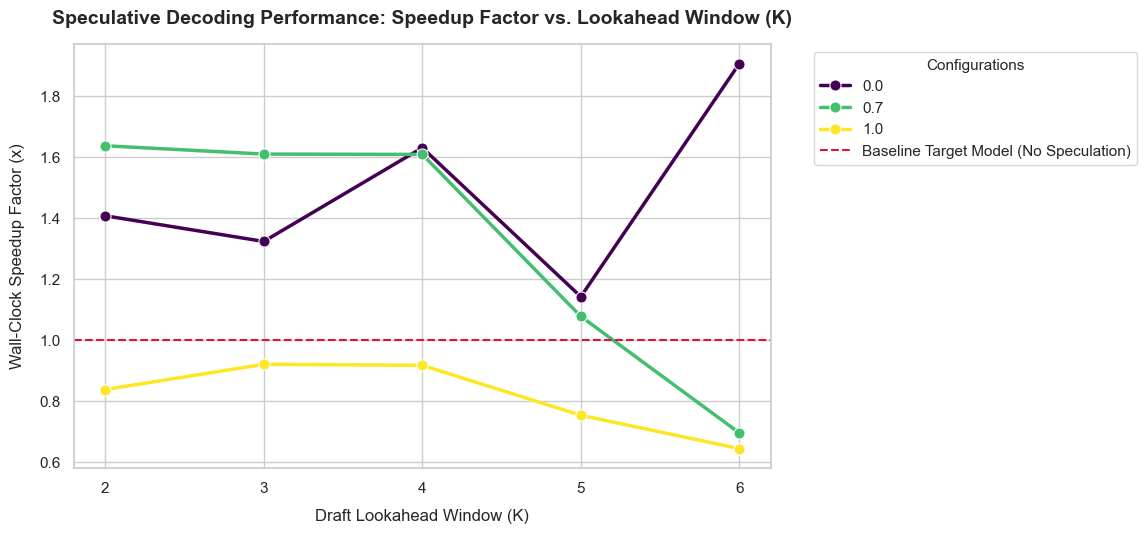

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a professional plotting style for our portfolio
sns.set_theme(style="whitegrid")

# Create subplots (avoiding .figure() to maintain clean state handling)
fig, ax = plt.subplots(figsize=(9, 5.5))

# Plot the speedup curves for each temperature configuration
sns.lineplot(
    data=df_results,
    x="Lookahead_K",
    y="Speedup_Factor",
    hue="Temperature",
    marker="o",
    linewidth=2.5,
    markersize=8,
    palette="viridis",
    ax=ax,
)

# Add a horizontal reference line representing the baseline target model (Speedup = 1.0)
ax.axhline(
    y=1.0,
    color="crimson",
    linestyle="--",
    linewidth=1.5,
    label="Baseline Target Model (No Speculation)",
)

# Refine labels and titles to ensure they aren't truncated or overlapping
ax.set_title(
    "Speculative Decoding Performance: Speedup Factor vs. Lookahead Window (K)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Draft Lookahead Window (K)", fontsize=12, labelpad=10)
ax.set_ylabel("Wall-Clock Speedup Factor (x)", fontsize=12, labelpad=10)

# Set clean, discrete markers on the X-axis corresponding to our exact K choices
ax.set_xticks(df_results["Lookahead_K"].unique())

# Place the legend in an empty area where it won't block the data trends
ax.legend(
    title="Configurations", 
    title_fontsize="11", 
    loc="upper left", 
    bbox_to_anchor=(1.05, 1), # Coordinates relative to the chart box
    frameon=True
)

# Save the high-res visualization directly to our workspace for our README
plt.savefig(
    "speculative_decoding_speedup.png",
    bbox_inches="tight",
    dpi=300,
)
print("📊 Chart successfully rendered and saved as 'speculative_decoding_speedup.png'!")

## Experiments

### Findings

* Running speculative decoding on short prompts like "India gained its" doesn't yield clear trends because the prompt provides very little contextual constraints. Because the text is wide open, the 124M draft model might guess words like "independence in 1947", while the 355M target model might prefer "freedom from British rule". This divergence instantly kills our Acceptance_Rate.
* (to-be-verified) Speed-up is more for deterministic tasks, like reciting a famous poem or the declaration of independence
* Average Speed-up & acceptance rate are inversely proportional to temperature: Clean monotonic effect. Mechanism: higher temperature → both models sample more stochastically → draft and target distributions diverge → more rejections → the draft's compute is wasted and we fall below baseline. At T=1.0 spec decoding actively hurts on our setup.
* Try instruction-tuned or chat models since they are more predictable.

### Future

1. Measure performance for short-prompt vs long-prompt. More context will force both models to align their internal probabilities, which should improve our acceptance rate.
2. Measure performance for open-ended task vs closed (like reciting the declaration of independence). The latter will force the model to align their probabilites.
3. Measure performance on a dataset of 20-30 prompts of different lengths and type